# Car Price Prediction

------------------------
------------------------

The dataset used in this notebook contains information about used cars. And the Model will try to predict the price of the car.

The columns in the given dataset are as follows:
- name
- year
- selling_price
- km_driven
- fuel
- seller_type
- transmission
- Owner

-------------
### Importing the Dependencies

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn import metrics

--------------
### Data Collection and Processing

In [5]:
# loading the data from a CSV file to a pandas dataframe
car_dataset = pd.read_csv('car_data.csv')

In [6]:
# inspecting the first 5 rows of the dataframe
car_dataset.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [7]:
# checking the number of rows and columns
car_dataset.shape

(301, 9)

In [8]:
# get some information about the dataset
car_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [9]:
# check the number of missing values from the dataset
car_dataset.isnull().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64

In [10]:
# checking the distrubition of categorical data
print(car_dataset.Fuel_Type.value_counts())
print(car_dataset.Seller_Type.value_counts())
print(car_dataset.Transmission.value_counts())

Fuel_Type
Petrol    239
Diesel     60
CNG         2
Name: count, dtype: int64
Seller_Type
Dealer        195
Individual    106
Name: count, dtype: int64
Transmission
Manual       261
Automatic     40
Name: count, dtype: int64


-------------
### Encoding the Categorical Data

In [12]:
# encoding "Fuel_Type" Column
car_dataset.replace({'Fuel_Type':{'Petrol':0, 'Diesel':1, 'CNG':2}}, inplace=True)

# encoding "Seller_Type" Column
car_dataset.replace({'Seller_Type':{'Dealer':0, 'Individual':1}}, inplace=True)

# encoding "Transmission" Column
car_dataset.replace({'Transmission':{'Manual':0, 'Automatic':1}}, inplace=True)

C:\Users\samir\AppData\Local\Temp\ipykernel_26208\1138597803.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  car_dataset.replace({'Fuel_Type':{'Petrol':0, 'Diesel':1, 'CNG':2}}, inplace=True)
C:\Users\samir\AppData\Local\Temp\ipykernel_26208\1138597803.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  car_dataset.replace({'Seller_Type':{'Dealer':0, 'Individual':1}}, inplace=True)
C:\Users\samir\AppData\Local\Temp\ipykernel_26208\1138597803.py:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be remov

In [13]:
car_dataset.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,0,0,0,0
1,sx4,2013,4.75,9.54,43000,1,0,0,0
2,ciaz,2017,7.25,9.85,6900,0,0,0,0
3,wagon r,2011,2.85,4.15,5200,0,0,0,0
4,swift,2014,4.60,6.87,42450,1,0,0,0


---------------------
### Splitting the data into Training and Test Data

Separate out the data into X features and y labels

In [16]:
X = car_dataset.drop(['Car_Name', 'Selling_Price'], axis=1)
y = car_dataset['Selling_Price']

Splitting Training and Test data

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

----------------
### Model Training
We will use Grid Search Model for Elastic Net

In [20]:
base_elastic_model = ElasticNet()

Set the parameters to compare on the Grid Search

In [22]:
param_grid = {'alpha': [0.1, 1, 5, 10, 50, 100],
              'l1_ratio': [.1, .5, .7, .9, .95, .99, 1]}

In [23]:
grid_model = GridSearchCV(estimator = base_elastic_model,
                          param_grid = param_grid,
                          scoring='neg_mean_squared_error',
                          cv = 5, verbose = 2)

Fit the train dataset to the model

In [25]:
grid_model.fit(X_train, y_train)

Fitting 5 folds for each of 42 candidates, totalling 210 fits
[CV] END ............................alpha=0.1, l1_ratio=0.1; total time=   0.0s
[CV] END ............................alpha=0.1, l1_ratio=0.1; total time=   0.0s
[CV] END ............................alpha=0.1, l1_ratio=0.1; total time=   0.0s
[CV] END ............................alpha=0.1, l1_ratio=0.1; total time=   0.0s
[CV] END ............................alpha=0.1, l1_ratio=0.1; total time=   0.0s
[CV] END ............................alpha=0.1, l1_ratio=0.5; total time=   0.0s
[CV] END ............................alpha=0.1, l1_ratio=0.5; total time=   0.0s
[CV] END ............................alpha=0.1, l1_ratio=0.5; total time=   0.0s
[CV] END ............................alpha=0.1, l1_ratio=0.5; total time=   0.0s
[CV] END ............................alpha=0.1, l1_ratio=0.5; total time=   0.0s
[CV] END ............................alpha=0.1, l1_ratio=0.7; total time=   0.0s
[CV] END ............................alpha=0.1,

GridSearchCV(cv=5, estimator=ElasticNet(),
             param_grid={'alpha': [0.1, 1, 5, 10, 50, 100],
                         'l1_ratio': [0.1, 0.5, 0.7, 0.9, 0.95, 0.99, 1]},
             scoring='neg_mean_squared_error', verbose=2)

As we see from the best parameters that the Grid Search Model prefers the Lasso Regression

In [27]:
grid_model.best_estimator_

ElasticNet(alpha=0.1, l1_ratio=0.1)

In [28]:
grid_model.best_params_

{'alpha': 0.1, 'l1_ratio': 0.1}

Now we use the Test set to get the predicted y values

In [30]:
y_pred = grid_model.predict(X_test)

--------------
### Metrics
We use some metrics to measure the error rates

In [32]:
mean_absolute_error(y_test, y_pred)

1.2626809435756425

In [33]:
np.sqrt(mean_squared_error(y_test, y_pred))

2.338957126181039

In [34]:
error_score = metrics.r2_score(y_test, y_pred)
print("R squared Error: ", error_score)

R squared Error:  0.845278808289218


A plot to show that the actual price and the predicted price is almost the same

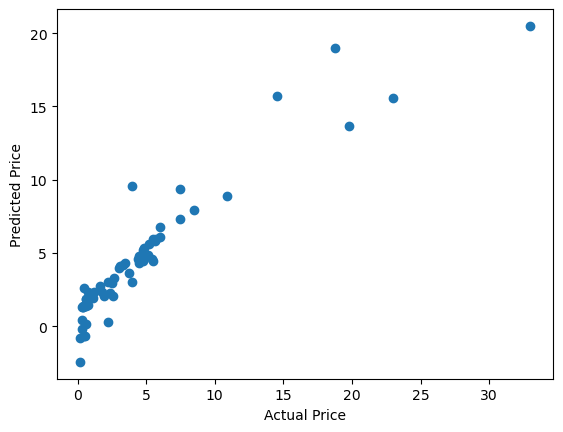

In [36]:
plt.scatter(y_test, y_pred)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.show()